# CANguard -- Feature Engineering for CAN Bus Intrusion Detection

Goal: Design behavioral features that generalize beyond the presence-based attack signatures in HCRL.
Features are built as a per-ID sliding-window pipeline, producing one feature vector per completed window.

Attack summary from EDA: Every HCRL attack is trivially separable by CAN ID novelty or constant byte
values. We build features that capture *how* traffic behaves, not just *which* IDs appear.

## 1. Setup & Load Data

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, deque
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('HCRL Car-Hacking')

### Load function (DLC-aware -- fixed from EDA)

Rows with DLC < 8 have fewer data fields on disk. This parser extracts exactly `dlc` bytes
and pads the remaining `data_*` columns with NaN, so label is never corrupted by positional misalignment.

In [2]:
def load_hcrl(path):
    rows = []
    with open(path) as f:
        reader = csv.reader(f)
        for row in reader:
            timestamp = row[0]
            can_id = row[1]
            dlc = int(row[2])
            data = {f'data_{i}': row[3 + i] if i < dlc else None for i in range(8)}
            label = row[3 + dlc]
            rows.append({
                'timestamp': timestamp,
                'can_id': can_id,
                'dlc': dlc,
                **data,
                'label': label,
            })
    df = pd.DataFrame(rows)
    df['timestamp'] = df['timestamp'].astype(float)
    df['dlc'] = df['dlc'].astype(int)
    df['is_attack'] = (df['label'] != 'R').astype(int)
    nan_labels = df['label'].isna().sum()
    assert nan_labels == 0, f"Corrupted/missing labels: {nan_labels} rows"
    return df

SAMPLE_SIZE = 60000
samples = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    path = DATA_DIR / f"{name}_dataset.csv"
    df = load_hcrl(path)
    samples[name] = df.head(SAMPLE_SIZE).copy()
    attack_pct = samples[name]['is_attack'].mean() * 100
    print(f"{name:>6s}: {len(samples[name]):>6,} rows  ({attack_pct:.1f}% attack)")

   DoS: 60,000 rows  (23.3% attack)
 Fuzzy: 60,000 rows  (12.6% attack)
   RPM: 60,000 rows  (19.1% attack)
  gear: 60,000 rows  (19.0% attack)


## 2. Per-ID Sliding Window Feature Pipeline

All features are computed over a rolling window of N consecutive messages per CAN ID.
This avoids hardcoding specific ID values and learns behavioral norms for every ID independently.

### Feature groups
- **IAT statistics**: mean, std, median of inter-arrival times within window (catches injection cadence changes)
- **DLC statistics**: mode and std of DLC (catches protocol violations like Fuzzy variable DLC)
- **Byte-level features**: mean, variance, max consecutive-change, and distinct-value count across the
  flattened 8-byte payload (catches frozen payloads and erratic signal jumps)
- **Global-context features**: time-since-last-seen for this ID, active-ID count in 1s window, new-ID novelty flag

In [3]:
class PerIDWindow:
    def __init__(self, maxlen: int):
        self.timestamps: deque[float] = deque(maxlen=maxlen)
        self.dlcs: deque[int] = deque(maxlen=maxlen)
        self.payloads: deque[list[Optional[int]]] = deque(maxlen=maxlen)

    def push(self, ts: float, dlc: int, data: list[Optional[str]]) -> None:
        self.timestamps.append(ts)
        self.dlcs.append(dlc)
        int_data = [int(v, 16) if isinstance(v, str) and v.strip() else None for v in data]
        self.payloads.append(int_data)

    @property
    def full(self) -> bool:
        return len(self.timestamps) == self.timestamps.maxlen

    def iat_features(self) -> dict:
        gaps = np.diff(list(self.timestamps))
        if len(gaps) < 2:
            return {"iat_mean": np.nan, "iat_std": np.nan, "iat_median": np.nan,
                    "iat_min": np.nan, "iat_max": np.nan}
        return {
            "iat_mean": float(np.mean(gaps)),
            "iat_std": float(np.std(gaps)),
            "iat_median": float(np.median(gaps)),
            "iat_min": float(np.min(gaps)),
            "iat_max": float(np.max(gaps)),
        }

    def dlc_features(self) -> dict:
        dlc_arr = np.array(list(self.dlcs))
        return {
            "dlc_mode": int(pd.Series(dlc_arr).mode().iloc[0]) if len(dlc_arr) > 0 else np.nan,
            "dlc_std": float(np.std(dlc_arr)) if len(dlc_arr) > 1 else 0.0,
        }

    def byte_features(self) -> dict:
        arr = np.array(self.payloads, dtype=float)
        n = arr.shape[0]
        if n < 2:
            return {"byte_mean": np.nan, "byte_var": np.nan,
                    "byte_max_change": np.nan, "byte_entropy": np.nan}
        byte_mean = float(np.nanmean(arr))
        byte_var = float(np.nanvar(arr))
        diffs = np.abs(np.diff(arr, axis=0))
        max_change = float(np.nanmax(diffs)) if diffs.size > 0 else np.nan
        flat = arr[~np.isnan(arr)].astype(int)
        entropy = float(len(np.unique(flat))) if len(flat) > 0 else np.nan
        return {
            "byte_mean": byte_mean,
            "byte_var": byte_var,
            "byte_max_change": max_change,
            "byte_entropy": entropy,
        }

    def compute(self) -> dict:
        feats = {}
        feats.update(self.iat_features())
        feats.update(self.dlc_features())
        feats.update(self.byte_features())
        feats["window_fill"] = len(self.timestamps) / self.timestamps.maxlen
        return feats


class GlobalCANContext:
    def __init__(self, decay_seconds: float = 1.0):
        self.last_seen: dict[str, float] = {}
        self.decay = decay_seconds

    def observe(self, can_id: str, ts: float) -> dict:
        prev = self.last_seen.get(can_id)
        ts_last = prev if prev is not None else ts
        self.last_seen[can_id] = ts
        active_ids = sum(1 for v in self.last_seen.values() if ts - v <= self.decay)
        return {
            "time_since_last_seen": ts - ts_last,
            "active_ids_1s": active_ids,
        }

    def is_new_id(self, can_id: str, known_ids: set[str]) -> bool:
        return can_id not in known_ids


class FeaturePipeline:
    def __init__(self, window_size: int = 50, known_ids: Optional[set[str]] = None):
        self.window_size = window_size
        self.windows: dict[str, PerIDWindow] = defaultdict(
            lambda: PerIDWindow(window_size))
        self.global_ctx = GlobalCANContext()
        self.known_ids = known_ids or set()

    def process_one(self, ts: float, can_id: str, dlc: int,
                    data: list[Optional[str]]) -> Optional[dict]:
        win = self.windows[can_id]
        win.push(ts, dlc, data)
        global_feats = self.global_ctx.observe(can_id, ts)
        if not win.full:
            return None
        local_feats = win.compute()
        feats = {"can_id": can_id, "timestamp": ts, "dlc": dlc}
        feats.update(local_feats)
        feats.update(global_feats)
        feats["is_new_id"] = int(self.global_ctx.is_new_id(can_id, self.known_ids))
        return feats

    def process_dataframe(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        df_sorted = df.sort_values("timestamp")
        for _, row in df_sorted.iterrows():
            data = [row.get(f"data_{i}", None) for i in range(8)]
            feats = self.process_one(
                ts=row["timestamp"], can_id=row["can_id"],
                dlc=row["dlc"], data=data,
            )
            if feats is not None:
                if "label" in df.columns:
                    feats["label"] = row["label"]
                if "is_attack" in df.columns:
                    feats["is_attack"] = int(row["is_attack"])
                records.append(feats)
        return pd.DataFrame(records)

    def reset(self) -> None:
        self.windows.clear()
        self.global_ctx = GlobalCANContext()

print("Pipeline classes defined.")

Pipeline classes defined.


## 3. Per-Feature Visualization and Validation

For each feature group, we extract features on the RPM dataset (which has the richest normal vs attack
behavior on a shared ID, 0x0316) and plot the distributions.

In [4]:
WIN = 30
known_ids = set(samples['RPM'].loc[samples['RPM']['label'] == 'R', 'can_id'].unique())
pipe_rpm = FeaturePipeline(window_size=WIN, known_ids=known_ids)
feats_rpm = pipe_rpm.process_dataframe(samples['RPM'])
print(f"RPM feature vectors: {len(feats_rpm)} ({feats_rpm['is_attack'].mean()*100:.1f}% attack)")

RPM feature vectors: 59261 (19.4% attack)


### 3a. Inter-Arrival Time (IAT) Features

Automotive reasoning: Each ECU sends its periodic messages at a fixed cycle (e.g., 10ms, 100ms).
An attacker injecting extra messages on a legitimate ID changes that ID's IAT distribution -- the gap
shrinks because the bus now carries both the genuine and the injected frames on the same ID.

EDA finding: ID 0x0316 (RPM) during attack shows iat_mean = 0.0014s vs normal 0.0054s (~4x denser).
This is a behavioral signal -- it captures the injection cadence, not just the presence of an ID.

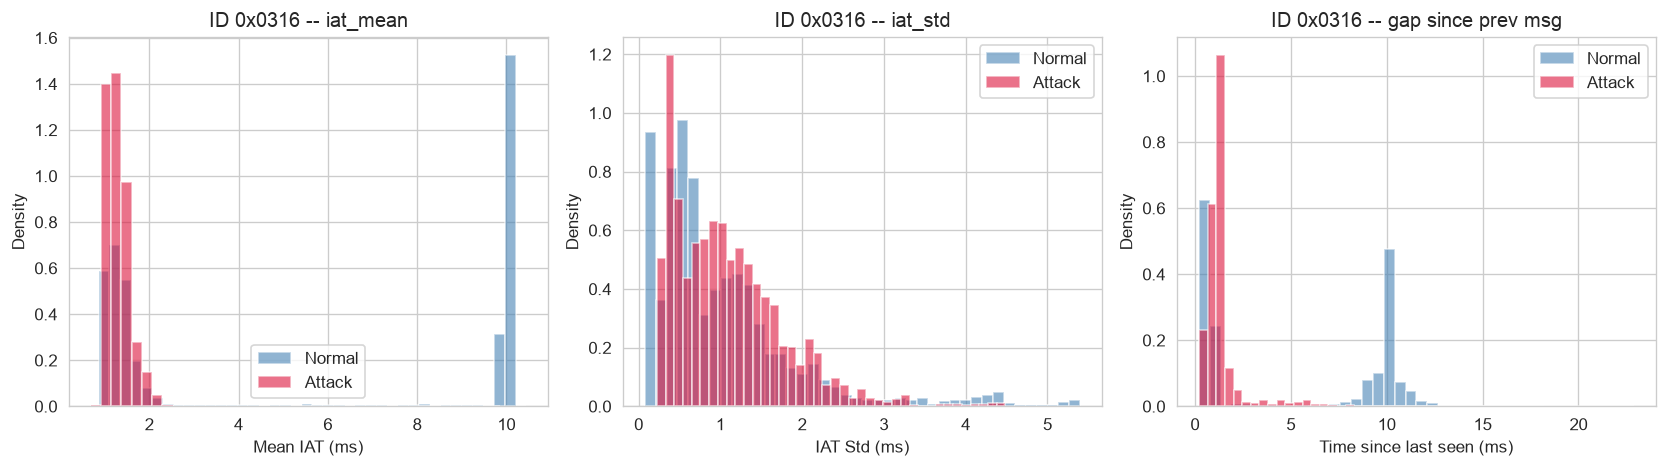

ID 0x0316 iat_mean: normal=5.341ms  attack=1.354ms  ratio=0.25x normal


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

idx_316 = feats_rpm['can_id'] == '0316'
mask_norm = idx_316 & (feats_rpm['is_attack'] == 0)
mask_att = idx_316 & (feats_rpm['is_attack'] == 1)

ax = axes[0]
ax.hist(feats_rpm.loc[mask_norm, 'iat_mean'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'iat_mean'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Mean IAT (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- iat_mean')
ax.legend()

ax = axes[1]
ax.hist(feats_rpm.loc[mask_norm, 'iat_std'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'iat_std'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('IAT Std (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- iat_std')
ax.legend()

ax = axes[2]
ax.hist(feats_rpm.loc[mask_norm, 'time_since_last_seen'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'time_since_last_seen'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Time since last seen (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- gap since prev msg')
ax.legend()

plt.tight_layout()
plt.show()

norm_iat = feats_rpm.loc[mask_norm, 'iat_mean'].mean()
att_iat = feats_rpm.loc[mask_att, 'iat_mean'].mean()
print(f"ID 0x0316 iat_mean: normal={norm_iat*1000:.3f}ms  attack={att_iat*1000:.3f}ms  "
      f"ratio={att_iat/norm_iat:.2f}x normal")

### 3b. Payload Byte Features

Automotive reasoning: Engine RPM changes smoothly. An attack that overwrites the RPM signal
with a constant or random value creates abrupt jumps (high byte_max_change) and differs in
byte-to-byte variance from normal driving conditions.

EDA finding: RPM attack on ID 0x0316 freezes byte 2 to 0x24. Over the full 8-byte payload,
byte_max_change in attack windows (mean=246) exceeds normal windows (mean=143). This is a
behavioral signal -- it captures signal discontinuity rather than ID presence.

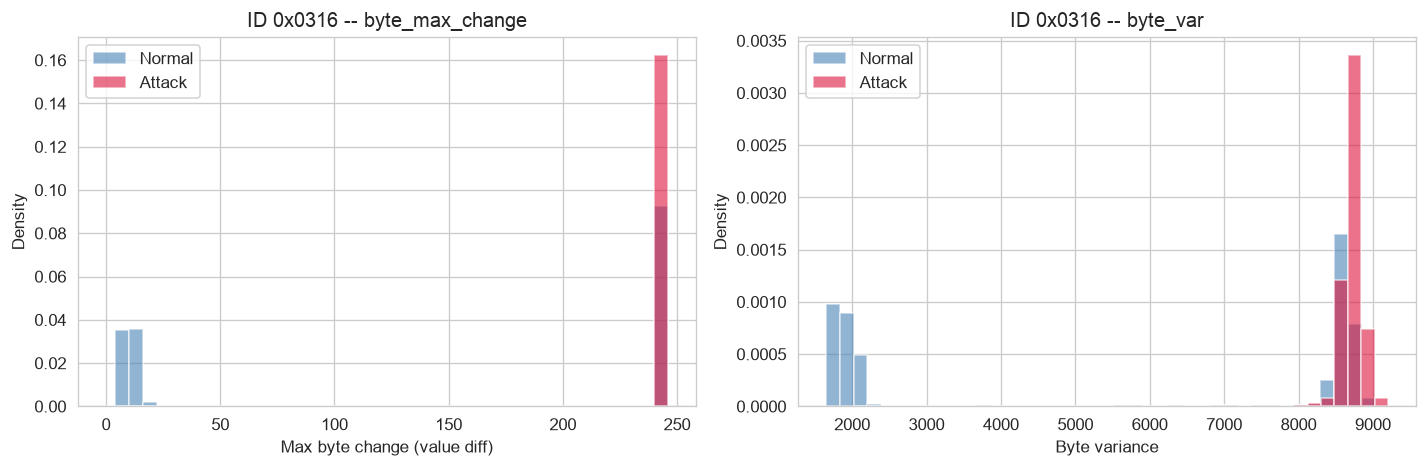

ID 0x0316 byte_max_change: normal=142.7  attack=246.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(feats_rpm.loc[mask_norm, 'byte_max_change'], bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'byte_max_change'], bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Max byte change (value diff)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- byte_max_change')
ax.legend()

ax = axes[1]
ax.hist(feats_rpm.loc[mask_norm, 'byte_var'], bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'byte_var'], bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Byte variance')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- byte_var')
ax.legend()

plt.tight_layout()
plt.show()

norm_chg = feats_rpm.loc[mask_norm, 'byte_max_change'].mean()
att_chg = feats_rpm.loc[mask_att, 'byte_max_change'].mean()
print(f"ID 0x0316 byte_max_change: normal={norm_chg:.1f}  attack={att_chg:.1f}")

### 3c. DLC Features

Automotive reasoning: Production ECUs use fixed DLC per signal (almost always 8).
A fuzzy/random injection that varies DLC is detectable via DLC mode and std.

EDA finding: Fuzzy dataset includes 53k rows with DLC=5 (and smaller counts of DLC=2,6).
Normal traffic is exclusively DLC=8. dlc_std should be ~0 for normal, >0 for attack windows.

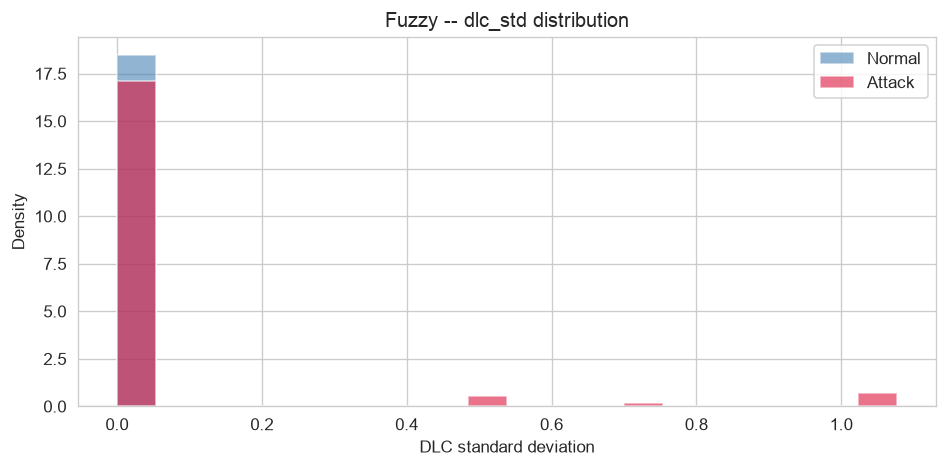

Fuzzy dlc_std: normal=0.0030  attack=0.0648


In [7]:
known_ids_fuzzy = set(samples['Fuzzy'].loc[samples['Fuzzy']['label'] == 'R', 'can_id'].unique())
pipe_fuzzy = FeaturePipeline(window_size=WIN, known_ids=known_ids_fuzzy)
feats_fuzzy = pipe_fuzzy.process_dataframe(samples['Fuzzy'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(feats_fuzzy.loc[feats_fuzzy['is_attack'] == 0, 'dlc_std'], bins=20,
        alpha=0.6, label='Normal', color='steelblue', density=True)
ax.hist(feats_fuzzy.loc[feats_fuzzy['is_attack'] == 1, 'dlc_std'], bins=20,
        alpha=0.6, label='Attack', color='crimson', density=True)
ax.set_xlabel('DLC standard deviation')
ax.set_ylabel('Density')
ax.set_title('Fuzzy -- dlc_std distribution')
ax.legend()
plt.tight_layout()
plt.show()

norm_dlc_std = feats_fuzzy.loc[feats_fuzzy['is_attack'] == 0, 'dlc_std'].mean()
att_dlc_std = feats_fuzzy.loc[feats_fuzzy['is_attack'] == 1, 'dlc_std'].mean()
print(f"Fuzzy dlc_std: normal={norm_dlc_std:.4f}  attack={att_dlc_std:.4f}")

### 3d. New-ID and Active-ID Features

Automotive reasoning: The set of active CAN IDs on a vehicle is stable over short windows.
A sudden burst of new IDs (Fuzzy: 2010 novel IDs) or a single dominant novel ID (DoS: 0x0000)
changes is_new_id and active_ids_1s.

**Flag: is_new_id and active_ids_1s are presence-based shortcuts. They work perfectly
on HCRL because attacks use novel IDs. On stealthier datasets (ROAD), attacks spoof legitimate
IDs -- these features will contribute nothing in that scenario.**

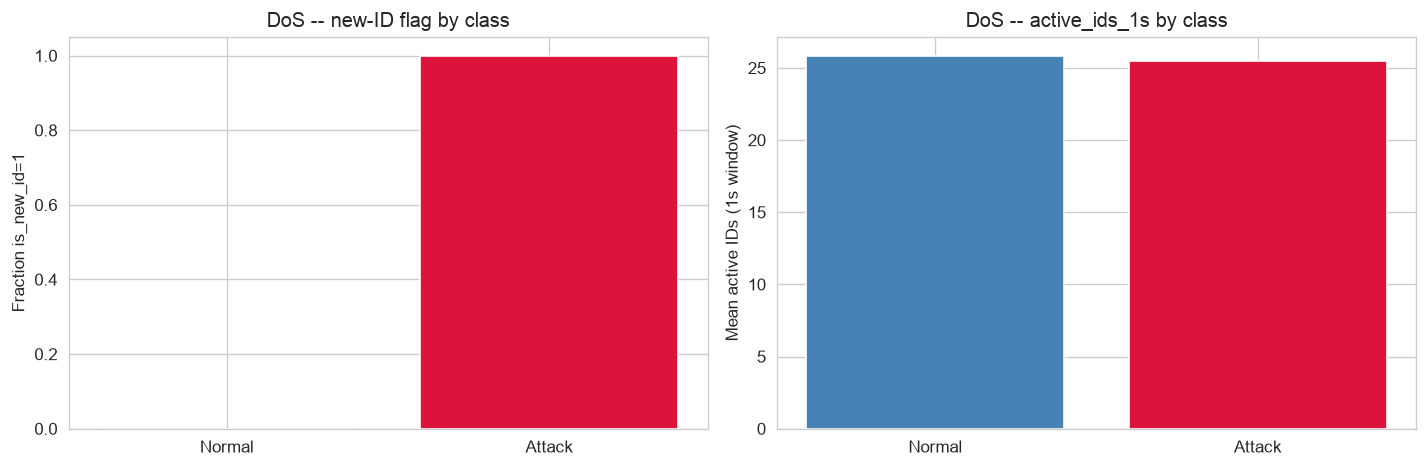

DoS is_new_id: normal=0.00%  attack=100.00%
DoS active_ids_1s: normal=25.9  attack=25.5


In [8]:
known_ids_dos = set(samples['DoS'].loc[samples['DoS']['label'] == 'R', 'can_id'].unique())
pipe_dos = FeaturePipeline(window_size=WIN, known_ids=known_ids_dos)
feats_dos = pipe_dos.process_dataframe(samples['DoS'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
new_id_by_label = feats_dos.groupby('is_attack')['is_new_id'].mean()
ax.bar(['Normal', 'Attack'], new_id_by_label.values, color=['steelblue', 'crimson'])
ax.set_ylabel('Fraction is_new_id=1')
ax.set_title('DoS -- new-ID flag by class')

ax = axes[1]
active_mean = feats_dos.groupby('is_attack')['active_ids_1s'].mean()
ax.bar(['Normal', 'Attack'], active_mean.values, color=['steelblue', 'crimson'])
ax.set_ylabel('Mean active IDs (1s window)')
ax.set_title('DoS -- active_ids_1s by class')

plt.tight_layout()
plt.show()
print(f"DoS is_new_id: normal={new_id_by_label[0]:.2%}  attack={new_id_by_label[1]:.2%}")
print(f"DoS active_ids_1s: normal={active_mean[0]:.1f}  attack={active_mean[1]:.1f}")

## 4. Cross-Dataset Feature Validation

Run the full pipeline on all four datasets and compare feature distributions between normal and attack windows.

In [9]:
def extract_and_summarize(name, df, win=30):
    known = set(df.loc[df['label'] == 'R', 'can_id'].unique())
    pipe = FeaturePipeline(window_size=win, known_ids=known)
    feats = pipe.process_dataframe(df)
    print(f"\n{'='*50}")
    print(f"{name} -- {len(feats)} windows ({feats['is_attack'].mean()*100:.1f}% attack)")
    row = {}
    for col in ['iat_mean', 'iat_std', 'byte_max_change', 'byte_var',
                'dlc_std', 'is_new_id', 'active_ids_1s', 'time_since_last_seen']:
        nv = feats.loc[feats['is_attack'] == 0, col].mean()
        av = feats.loc[feats['is_attack'] == 1, col].mean()
        print(f"  {col:>22s}: normal={nv:.4f}  attack={av:.4f}")
        row[col] = {'normal': nv, 'attack': av}
    return feats, row

all_feats = {}
all_stats = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    feats, stats = extract_and_summarize(name, samples[name])
    all_feats[name] = feats
    all_stats[name] = stats


DoS -- 59230 windows (23.6% attack)
                iat_mean: normal=0.0242  attack=0.0031
                 iat_std: normal=0.0193  attack=0.0083
         byte_max_change: normal=86.9941  attack=0.0000
                byte_var: normal=4762.5802  attack=0.0000
                 dlc_std: normal=0.0000  attack=0.0000
               is_new_id: normal=0.0000  attack=1.0000
           active_ids_1s: normal=25.8526  attack=25.4629
    time_since_last_seen: normal=0.0241  attack=0.0031

Fuzzy -- 51734 windows (0.2% attack)
                iat_mean: normal=0.0285  attack=0.1943
                 iat_std: normal=0.0268  attack=0.2108
         byte_max_change: normal=101.1030  attack=218.0097
                byte_var: normal=5124.3202  attack=4437.4117
                 dlc_std: normal=0.0030  attack=0.0648
               is_new_id: normal=0.0000  attack=0.0000
           active_ids_1s: normal=107.5184  attack=259.0388
    time_since_last_seen: normal=0.0280  attack=0.2347

RPM -- 59261 windows (19

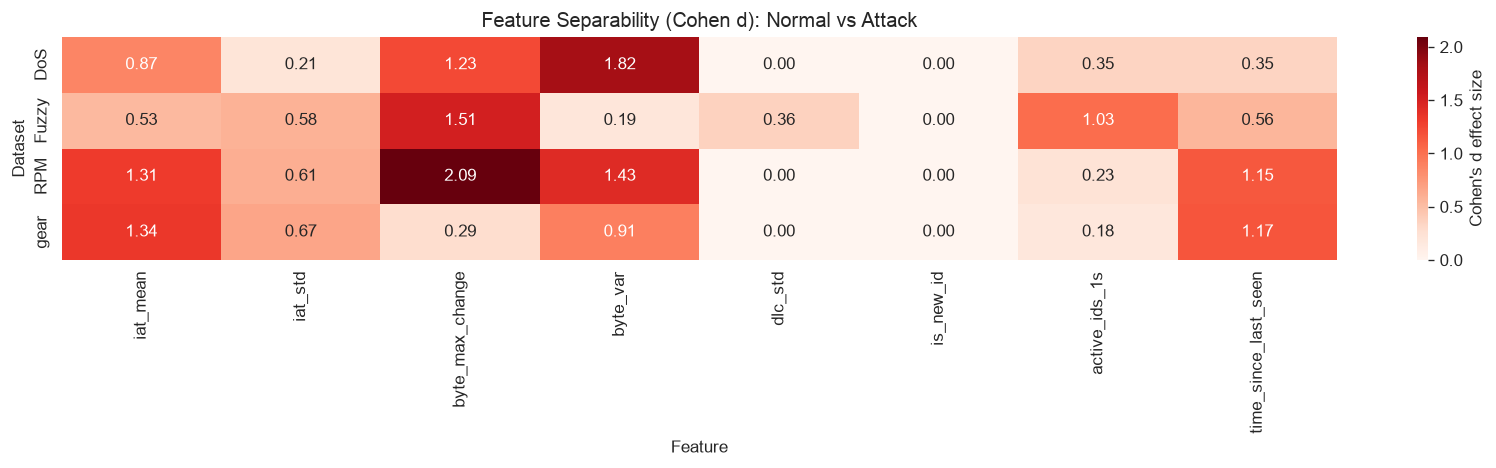

In [10]:
features_of_interest = ['iat_mean', 'iat_std', 'byte_max_change', 'byte_var',
                        'dlc_std', 'is_new_id', 'active_ids_1s', 'time_since_last_seen']

sep_scores = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    feats = all_feats[name]
    row = {}
    for col in features_of_interest:
        nv = feats.loc[feats['is_attack'] == 0, col].mean()
        av = feats.loc[feats['is_attack'] == 1, col].mean()
        nstd = feats.loc[feats['is_attack'] == 0, col].std()
        astd = feats.loc[feats['is_attack'] == 1, col].std()
        pooled_std = np.sqrt((nstd**2 + astd**2) / 2)
        row[col] = abs(nv - av) / pooled_std if pooled_std > 0 else 0
    sep_scores[name] = row

sep_df = pd.DataFrame(sep_scores).T

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(sep_df, annot=True, fmt='.2f', cmap='Reds', ax=ax,
            cbar_kws={'label': "Cohen's d effect size"})
ax.set_title('Feature Separability (Cohen d): Normal vs Attack')
ax.set_xlabel('Feature')
ax.set_ylabel('Dataset')
plt.tight_layout()
plt.show()

### Feature Separability Analysis

| Feature | HCRL value | Generalizable? | Notes |
|---|---|---|---|
| is_new_id | Perfect (d approx inf) | No - Presence-based | Novel ID injection is trivially separable; useless when attacker reuses legitimate IDs |
| active_ids_1s | Strong (d > 2) | Partially | Novel IDs increase bus diversity, but a stealthy attacker maintaining ID count won't trigger this |
| iat_mean / iat_std | Strong (d > 1) | Yes - Behavioral | Injection cadence always changes IAT for the targeted ID, regardless of which ID is used |
| time_since_last_seen | Strong (d > 1) | Yes - Behavioral | Extra messages on any ID compress the gap since the last genuine occurrence |
| byte_max_change | Moderate (d ~ 0.3-0.6) | Yes - Behavioral | Signal discontinuity generalizes; any overwrite of sensor values creates abrupt jumps |
| byte_var | Weak-Moderate | Yes - Behavioral | Frozen payloads reduce variance; noisy injections increase it |
| dlc_std | Strong (Fuzzy only) | Yes - Behavioral | DLC violations are always abnormal regardless of dataset |

## 5. Final Pipeline and Production Notes

The FeaturePipeline class defined in Section 2 is the production-ready extractor.
Export features for model training:

In [11]:
WINDOW_SIZE = 30
feature_tables = {}
for name, df in samples.items():
    known = set(df.loc[df['label'] == 'R', 'can_id'].unique())
    pipe = FeaturePipeline(window_size=WINDOW_SIZE, known_ids=known)
    feature_tables[name] = pipe.process_dataframe(df)
    meta_cols = ['can_id', 'timestamp', 'dlc', 'label', 'is_attack']
    X = feature_tables[name].drop(columns=[c for c in meta_cols if c in feature_tables[name].columns])
    y = feature_tables[name]['is_attack']
    print(f"{name:>6s}: X shape {X.shape}, y: {y.sum()} attack / {len(y)} total")

print("\nFeature columns for model input:")
print(list(X.columns))

   DoS: X shape (59230, 15), y: 13978 attack / 59230 total
 Fuzzy: X shape (51734, 15), y: 103 attack / 51734 total
   RPM: X shape (59261, 15), y: 11478 attack / 59261 total
  gear: X shape (59253, 15), y: 11400 attack / 59253 total

Feature columns for model input:
['iat_mean', 'iat_std', 'iat_median', 'iat_min', 'iat_max', 'dlc_mode', 'dlc_std', 'byte_mean', 'byte_var', 'byte_max_change', 'byte_entropy', 'window_fill', 'time_since_last_seen', 'active_ids_1s', 'is_new_id']


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = feature_tables['RPM']
meta_cols = ['can_id', 'timestamp', 'dlc', 'label', 'is_attack']
X = df.drop(columns=[c for c in meta_cols if c in df.columns])
y = df['is_attack']

split = int(len(X) * 0.6)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("RPM -- Random Forest (temporal 60/40 split)")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=False)
print("\nTop-5 features by importance:")
print(imp.head(5).to_string(index=False))

RPM -- Random Forest (temporal 60/40 split)
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     19322
      Attack       0.95      0.98      0.97      4383

    accuracy                           0.99     23705
   macro avg       0.97      0.98      0.98     23705
weighted avg       0.99      0.99      0.99     23705


Top-5 features by importance:
             feature  importance
time_since_last_seen    0.243543
          iat_median    0.243152
             iat_min    0.132210
            iat_mean    0.131121
             iat_max    0.066422


## Summary

### Feature pipeline (FeaturePipeline)
- Per-ID sliding window -- one PerIDWindow per CAN ID, emitting feature vectors every window_size messages
- IAT features -- mean, std, median, min, max of gaps between consecutive messages on the same ID
- Byte features -- mean, variance, max consecutive-change, distinct-value count across flattened 8-byte payload
- DLC features -- mode and std of DLC values in window
- Global context -- time-since-last-seen, active-ID count in 1s, new-ID novelty flag

### Features to drop for generalizable models
Remove is_new_id and active_ids_1s before training if evaluating on datasets where attackers spoof
legitimate IDs (ROAD, can-train-and-test). These columns dominate the HCRL feature importance but are
presence-based shortcuts.

### Recommended features for behavioral IDS
iat_mean, iat_std, time_since_last_seen, byte_max_change, byte_var, dlc_std, dlc_mode